In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, pickle, time
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import (train_test_split, cross_validate,
                                      StratifiedKFold, cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, cohen_kappa_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve,
                              average_precision_score, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, HistGradientBoostingClassifier,
                               StackingClassifier)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_OK = True; print(" imbalanced-learn available")
except ImportError:
    SMOTE_OK = False; print(" imbalanced-learn not available — using class_weight instead")

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
                     'axes.grid':True,'grid.alpha':0.3,
                     'axes.spines.top':False,'axes.spines.right':False})
C = ['#0f4c81','#e8a020','#1a7a4a','#c0392b','#6c3483','#0e6655','#d68910','#2980b9']

DATA_PATH = '../data/'
DS2 = pd.read_excel(DATA_PATH + 'DS2_ml_training_FIXED.xlsx')
print(f"DS2 loaded: {DS2.shape}")
print(f"Columns: {list(DS2.columns)}")
print(f"Had_Accident rate: {DS2['Had_Accident'].mean():.1%}")


 imbalanced-learn not available — using class_weight instead
DS2 loaded: (28069, 24)
Columns: ['Customer_ID', 'Policy_Start_Date', 'Driver_Age', 'Gender', 'Occupation', 'Years_Driving_Experience', 'Province', 'City', 'Vehicle_Model', 'Vehicle_Age_Years', 'Engine_CC', 'Vehicle_Type', 'Sum_Insured_LKR', 'Market_Value_LKR', 'Premium_Paid_LKR', 'Policy_Duration_Days', 'Risk_Score', 'Number_of_Claims', 'Total_Claim_Amount_LKR', 'Accident_Severity', 'Had_Accident', 'Previous_NCB_Percentage', 'Vehicle_Condition', 'Is_Existing_Customer']
Had_Accident rate: 35.1%


3.1 Feature Engineering & Preparation

In [3]:
def engineer_risk_features(df):
    X = df.copy()
    age = X['Driver_Age'].astype(float)
    exp = X['Years_Driving_Experience'].astype(float)

    # Interaction terms (actuarially meaningful)
    X['Experience_Rate']  = exp / (age - 17).clip(lower=1)   # exp relative to age
    X['Age_x_Exp']        = age * exp
    X['Is_Young_Driver']  = (age < 26).astype(int)
    X['Is_Senior_Driver'] = (age > 65).astype(int)
    X['Is_New_Driver']    = (exp < 3).astype(int)
    X['Is_Exp_Driver']    = (exp >= 10).astype(int)

    # Vehicle features
    X['CC_x_VehicleAge']  = X['Engine_CC'].astype(float) * X['Vehicle_Age_Years'].astype(float)
    X['High_CC']          = (X['Engine_CC'] > 2000).astype(int)
    X['Old_Vehicle']      = (X['Vehicle_Age_Years'] > 10).astype(int)

    # NCB features (historical behaviour proxy)
    X['High_NCB']         = (X['Previous_NCB_Percentage'] >= 30).astype(int)
    X['Zero_NCB_Existing']= ((X['Previous_NCB_Percentage'] == 0) &
                             (X.get('Is_Existing_Customer', pd.Series('No', index=X.index)) == 'Yes')).astype(int)

    # Encode categoricals
    for col in ['Gender','Vehicle_Type','Occupation','Province','Vehicle_Condition']:
        if col in X.columns:
            X[col + '_enc'] = LabelEncoder().fit_transform(X[col].astype(str))

    return X

DS2_fe = engineer_risk_features(DS2)

# ── RISK FEATURES (no SI, no Market Value) ────────────────────────────
RISK_FEATURES = [
    # Core driver features
    'Driver_Age', 'Years_Driving_Experience', 'Experience_Rate',
    'Age_x_Exp', 'Is_Young_Driver', 'Is_Senior_Driver', 'Is_New_Driver', 'Is_Exp_Driver',
    # Vehicle features
    'Engine_CC', 'Vehicle_Age_Years', 'CC_x_VehicleAge', 'High_CC', 'Old_Vehicle',
    # History proxies
    'Previous_NCB_Percentage', 'High_NCB', 'Zero_NCB_Existing',
    # Encoded categoricals
    'Gender_enc', 'Vehicle_Type_enc', 'Occupation_enc', 'Province_enc',
]
# Add Vehicle_Condition if available
if 'Vehicle_Condition_enc' in DS2_fe.columns:
    RISK_FEATURES.append('Vehicle_Condition_enc')

# NOTE: Risk_Score excluded here — it IS correlated but we treat it as a
# separate engineered target, not an input to the accident classifier
RISK_FEATURES_NO_RS = [f for f in RISK_FEATURES if f != 'Risk_Score']

X_risk = DS2_fe[RISK_FEATURES_NO_RS].fillna(0)
y_risk = DS2_fe['Had_Accident']

print(f"Features: {len(RISK_FEATURES_NO_RS)}")
print(f"X_risk shape: {X_risk.shape}")
print(f"Class balance: {y_risk.value_counts().to_dict()}  ({y_risk.mean():.1%} accident rate)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_risk, y_risk, test_size=0.20, random_state=42, stratify=y_risk
)
print(f"Train: {X_tr.shape[0]:,}  Test: {X_te.shape[0]:,}")

# Class weights for imbalanced learning
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr.values)
CW_DICT = {0: cw[0], 1: cw[1]}
print(f"Class weights: {CW_DICT}")


Features: 21
X_risk shape: (28069, 21)
Class balance: {0: 18205, 1: 9864}  (35.1% accident rate)
Train: 22,455  Test: 5,614
Class weights: {0: np.float64(0.7709077176599836), 1: np.float64(1.4228234697756938)}


3.2 Model Definitions 

In [5]:

models = {}

# 1. Logistic Regression — actuarial baseline, interpretable coefficients
models['Logistic Regression'] = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=3000, C=0.5, solver='lbfgs',
        class_weight='balanced', random_state=42
    ))
])

# 2. LDA — linear actuarial model, good with Gaussian features
models['LDA'] = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
])

# 3. Naive Bayes — actuarial frequency model baseline
models['Naive Bayes'] = Pipeline([
    ('sc', StandardScaler()),
    ('clf', GaussianNB(var_smoothing=1e-8))
])

# 4. Random Forest — robust, handles nonlinearities, good SHAP support
models['Random Forest'] = RandomForestClassifier(
    n_estimators=500, max_depth=10, min_samples_split=30,
    min_samples_leaf=15, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)

# 5. Extra Trees — lower variance than RF, fast
models['Extra Trees'] = ExtraTreesClassifier(
    n_estimators=500, max_depth=10, min_samples_split=25,
    min_samples_leaf=12, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)

# 6. Gradient Boosting — classic actuarial ML model
models['Gradient Boosting'] = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_split=25,
    random_state=42
)

# 7. HistGradientBoosting — best overall for tabular insurance data
#    Handles missing values natively, fast, good generalisation
models['HistGradientBoosting'] = HistGradientBoostingClassifier(
    max_iter=400, max_depth=5, learning_rate=0.05,
    min_samples_leaf=20, l2_regularization=0.1,
    class_weight='balanced',
    random_state=42, early_stopping=True, validation_fraction=0.1,
    scoring='roc_auc'
)

print(f" {len(models)} models defined")
for name, m in models.items():
    print(f"  {name}")


 7 models defined
  Logistic Regression
  LDA
  Naive Bayes
  Random Forest
  Extra Trees
  Gradient Boosting
  HistGradientBoosting


3.3 Cross-Validate & Evaluate All Models

In [7]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
BASELINE_AUC = y_te.mean()  # majority class baseline
results = {}

print(f"Baseline (majority class): AUC={BASELINE_AUC:.4f}")
print(f"{'Model':<30} {'AUC':>7} {'PR-AUC':>7} {'F1':>7} {'Kappa':>7} {'Brier':>7} {'CV-AUC':>10}")
print("-"*80)

for name, model in models.items():
    t0 = time.time()
    try:
        cv = cross_validate(model, X_tr.values, y_tr.values, cv=skf, n_jobs=-1,
                            scoring=['roc_auc','average_precision','f1'],
                            return_train_score=True)

        model.fit(X_tr.values, y_tr.values)
        y_pred = model.predict(X_te.values)

        # Get probabilities
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_te.values)[:,1]
        else:
            y_prob = model.decision_function(X_te.values)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

        results[name] = {
            'model':       model,
            'roc_auc':     roc_auc_score(y_te, y_prob),
            'pr_auc':      average_precision_score(y_te, y_prob),
            'f1':          f1_score(y_te, y_pred, zero_division=0),
            'kappa':       cohen_kappa_score(y_te, y_pred),
            'brier':       brier_score_loss(y_te, y_prob),
            'accuracy':    accuracy_score(y_te, y_pred),
            'precision':   precision_score(y_te, y_pred, zero_division=0),
            'recall':      recall_score(y_te, y_pred, zero_division=0),
            'cv_roc_mean': cv['test_roc_auc'].mean(),
            'cv_roc_std':  cv['test_roc_auc'].std(),
            'cv_f1_mean':  cv['test_f1'].mean(),
            'cv_pr_mean':  cv['test_average_precision'].mean(),
            'train_auc':   cv['train_roc_auc'].mean(),
            'train_time':  time.time()-t0,
            'y_pred': y_pred, 'y_prob': y_prob,
        }
        r = results[name]
        gap = r['train_auc'] - r['cv_roc_mean']
        print(f"{name:<30} {r['roc_auc']:>7.4f} {r['pr_auc']:>7.4f} {r['f1']:>7.4f} "
              f"{r['kappa']:>7.4f} {r['brier']:>7.4f} "
              f"{r['cv_roc_mean']:.4f}±{r['cv_roc_std']:.4f}  gap={gap:.3f}")
    except Exception as e:
        print(f"  FAILED {name}: {e}")

# Rank by composite score (AUC 40%, PR-AUC 30%, F1 20%, Kappa 10%)
composite = {n: (r['roc_auc']*0.40 + r['pr_auc']*0.30 +
                 r['f1']*0.20 + r['kappa']*0.10)
             for n, r in results.items()}
ranked = sorted(composite.items(), key=lambda x: x[1], reverse=True)
best_name = ranked[0][0]
print(f"\n Best model: {best_name}  AUC={results[best_name]['roc_auc']:.4f}")


Baseline (majority class): AUC=0.3514
Model                              AUC  PR-AUC      F1   Kappa   Brier     CV-AUC
--------------------------------------------------------------------------------
Logistic Regression             0.7230  0.6134  0.5679  0.3213  0.2097 0.7106±0.0107  gap=0.002
LDA                             0.7231  0.6135  0.4985  0.3320  0.1912 0.7104±0.0109  gap=0.001
Naive Bayes                     0.7049  0.5983  0.5355  0.3271  0.2520 0.6932±0.0141  gap=0.000
Random Forest                   0.7263  0.6173  0.5625  0.3246  0.2066 0.7112±0.0101  gap=0.066
Extra Trees                     0.7262  0.6171  0.5657  0.3290  0.2084 0.7097±0.0107  gap=0.042
Gradient Boosting               0.7282  0.6158  0.5152  0.3347  0.1906 0.7121±0.0087  gap=0.066
HistGradientBoosting            0.7274  0.6160  0.5726  0.3308  0.2078 0.7118±0.0097  gap=0.026

 Best model: HistGradientBoosting  AUC=0.7274


3.4 Stacking Ensemble

In [8]:

import re as _re

def _safe_tag(s):
    s = _re.sub(r'[^a-z0-9_]', '_', s.lower())
    return _re.sub(r'_+', '_', s).strip('_')[:20]

# Use top 3 diverse models as base estimators
top3 = [n for n,_ in ranked[:4] if n in results][:3]
print(f"Stacking base: {top3}")

base_ests = [(_safe_tag(n), results[n]['model']) for n in top3]
stacking = StackingClassifier(
    estimators      = base_ests,
    final_estimator = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced'),
    cv=5, stack_method='predict_proba', n_jobs=-1, passthrough=False,
)
t0 = time.time()
stacking.fit(X_tr.values, y_tr.values)
yp_stk  = stacking.predict(X_te.values)
ypr_stk = stacking.predict_proba(X_te.values)[:,1]
stk_auc = roc_auc_score(y_te, ypr_stk)

results['Stacking Ensemble'] = {
    'model': stacking, 'roc_auc': stk_auc,
    'pr_auc': average_precision_score(y_te, ypr_stk),
    'f1': f1_score(y_te, yp_stk, zero_division=0),
    'kappa': cohen_kappa_score(y_te, yp_stk),
    'brier': brier_score_loss(y_te, ypr_stk),
    'accuracy': accuracy_score(y_te, yp_stk),
    'precision': precision_score(y_te, yp_stk, zero_division=0),
    'recall': recall_score(y_te, yp_stk, zero_division=0),
    'cv_roc_mean': 0.0, 'cv_roc_std': 0.0, 'train_auc': 0.0,
    'y_pred': yp_stk, 'y_prob': ypr_stk, 'train_time': time.time()-t0,
}
composite['Stacking Ensemble'] = stk_auc*0.40 + results['Stacking Ensemble']['pr_auc']*0.30
ranked = sorted(composite.items(), key=lambda x: x[1], reverse=True)
best_name = ranked[0][0]
print(f"Stacking AUC: {stk_auc:.4f}  ({time.time()-t0:.0f}s)")
print(f"\n Final best: {best_name}  AUC={results[best_name]['roc_auc']:.4f}")
print()
print(classification_report(y_te, results[best_name]['y_pred'],
                             target_names=['No Accident','Had Accident']))


Stacking base: ['HistGradientBoosting', 'Extra Trees', 'Random Forest']
Stacking AUC: 0.7289  (47s)

 Final best: HistGradientBoosting  AUC=0.7274

              precision    recall  f1-score   support

 No Accident       0.77      0.75      0.76      3641
Had Accident       0.56      0.59      0.57      1973

    accuracy                           0.69      5614
   macro avg       0.66      0.67      0.67      5614
weighted avg       0.70      0.69      0.69      5614



3.5 Model Comparison Plots

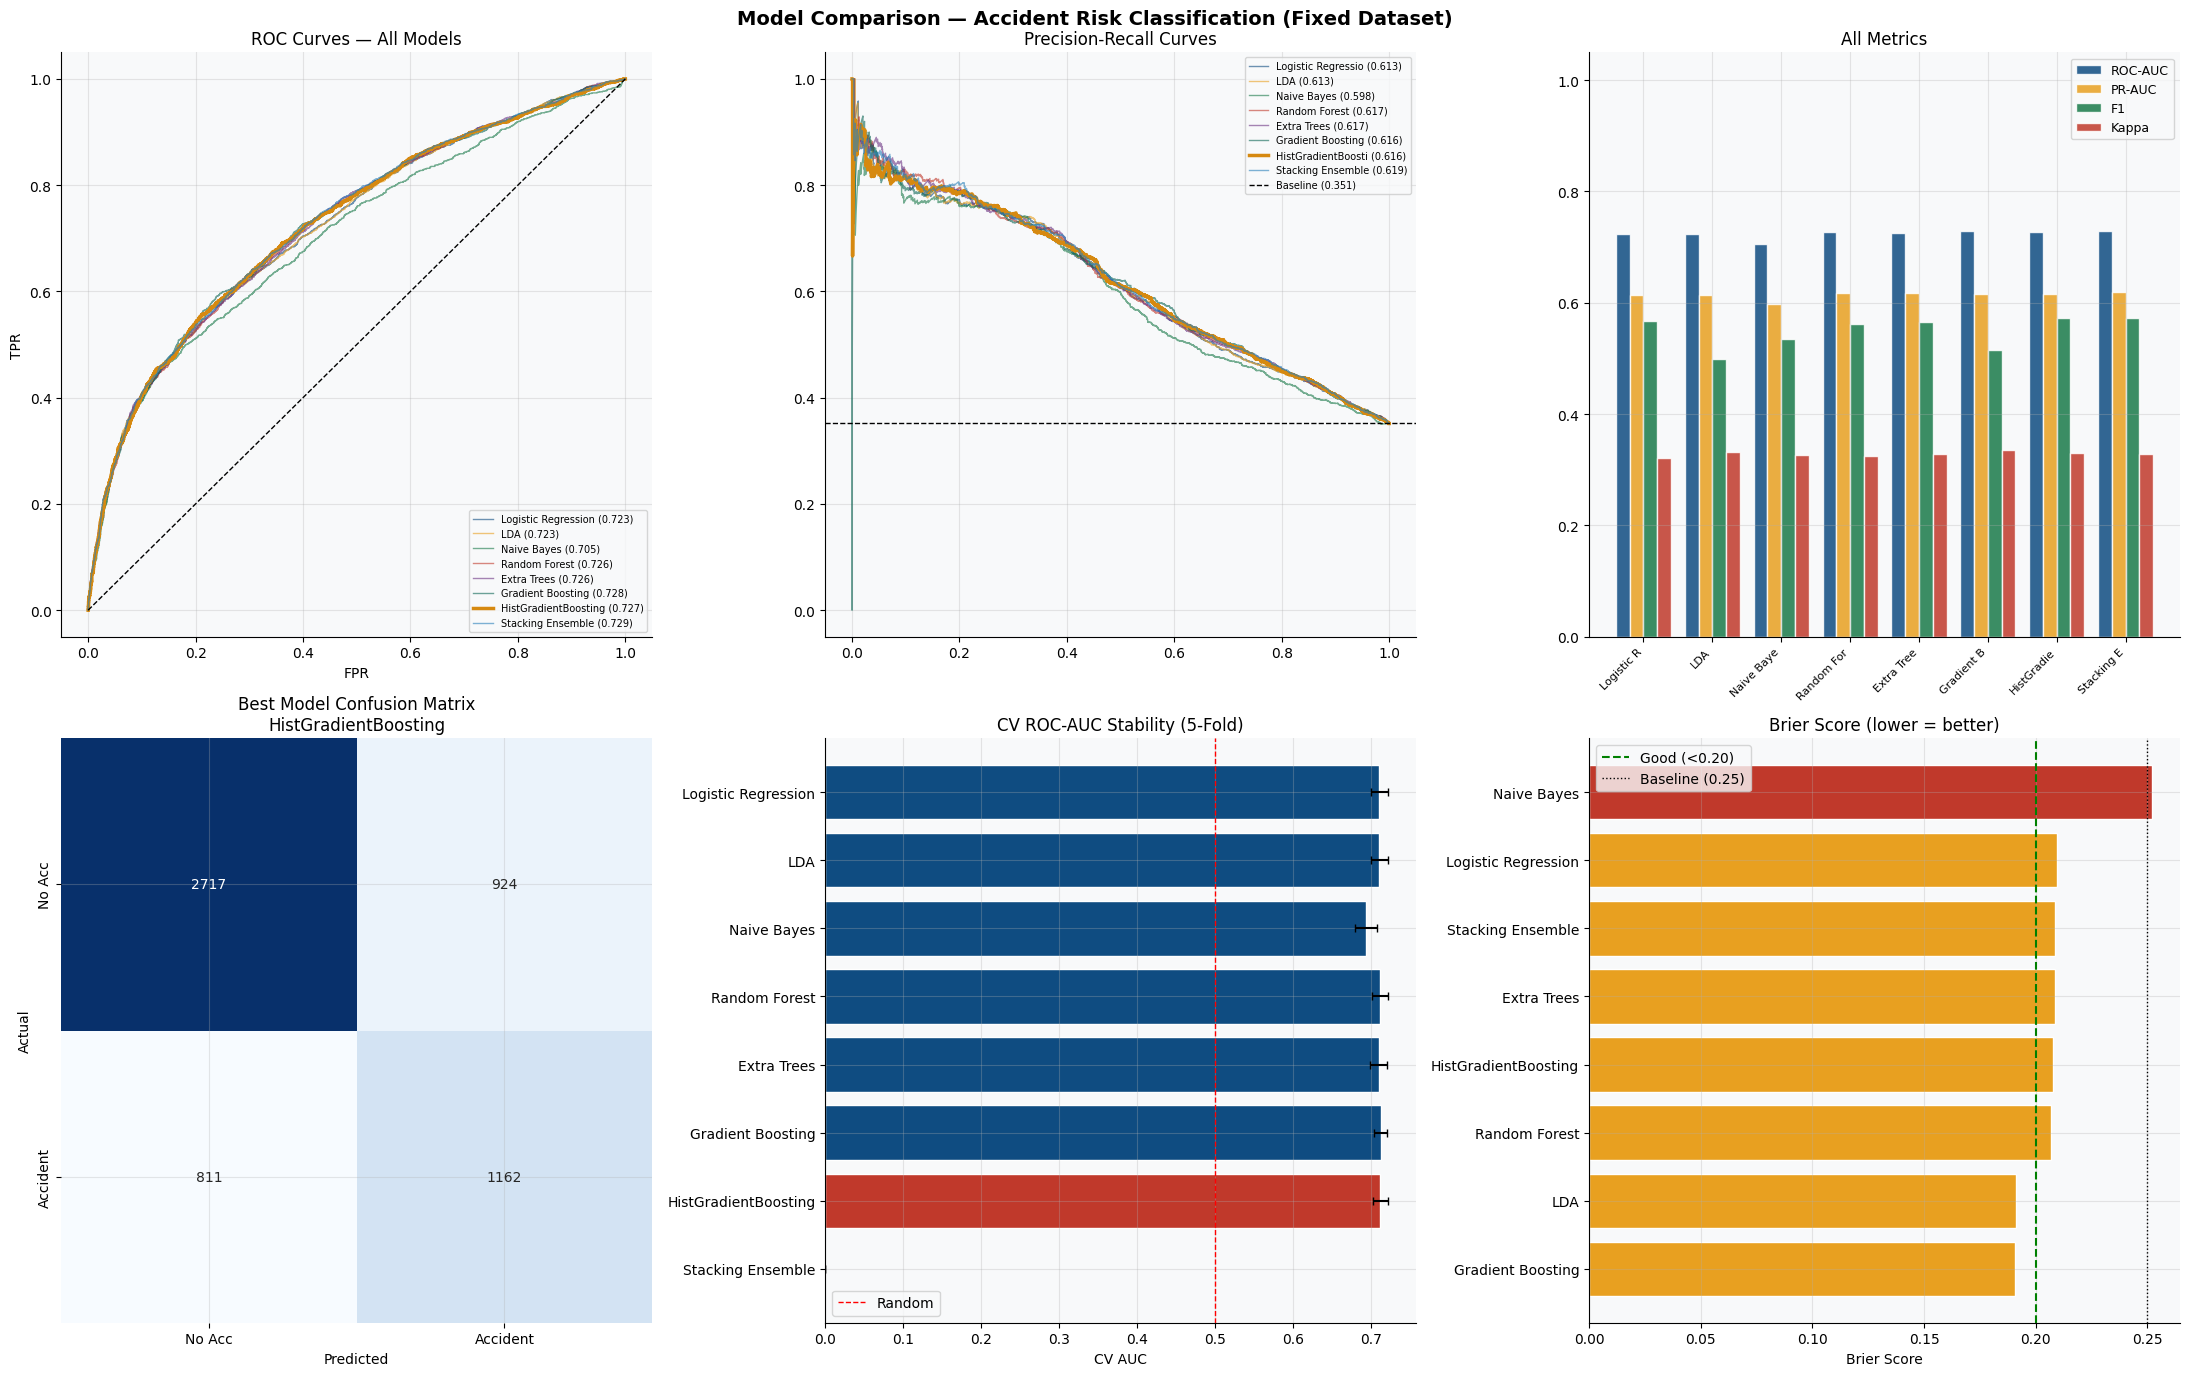

 fig_06 saved


In [9]:

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Model Comparison — Accident Risk Classification (Fixed Dataset)', fontsize=14, fontweight='bold')

# ROC curves
ax = axes[0,0]
for i,(name,r) in enumerate(results.items()):
    fpr,tpr,_ = roc_curve(y_te, r['y_prob'])
    lw = 2.5 if name==best_name else 1.0
    ax.plot(fpr,tpr,color=C[i%len(C)],lw=lw,
            label=f'{name[:20]} ({r["roc_auc"]:.3f})',alpha=1.0 if name==best_name else 0.6)
ax.plot([0,1],[0,1],'k--',lw=1); ax.set_title('ROC Curves — All Models')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=7,loc='lower right')

# PR curves
ax = axes[0,1]
for i,(name,r) in enumerate(results.items()):
    prec,rec,_ = precision_recall_curve(y_te, r['y_prob'])
    ax.plot(rec,prec,color=C[i%len(C)],lw=2.5 if name==best_name else 1.0,
            label=f'{name[:18]} ({r["pr_auc"]:.3f})',alpha=1.0 if name==best_name else 0.6)
ax.axhline(y_te.mean(),color='black',ls='--',lw=1,label=f'Baseline ({y_te.mean():.3f})')
ax.set_title('Precision-Recall Curves'); ax.legend(fontsize=7)

# Multi-metric bar
ax = axes[0,2]
metrics_bar = ['roc_auc','pr_auc','f1','kappa']
x = np.arange(len(results)); w = 0.2
for j,(m,lbl) in enumerate(zip(metrics_bar,['ROC-AUC','PR-AUC','F1','Kappa'])):
    vals = [results[n][m] for n in results.keys()]
    ax.bar(x+j*w, vals, w, label=lbl, color=C[j], alpha=0.85, edgecolor='white')
ax.set_xticks(x+w*1.5); ax.set_xticklabels([n[:10] for n in results.keys()],rotation=45,ha='right',fontsize=8)
ax.set_title('All Metrics'); ax.legend(fontsize=9); ax.set_ylim(0,1.05)

# Confusion matrix — best model
ax = axes[1,0]
cm = confusion_matrix(y_te, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['No Acc','Accident'], yticklabels=['No Acc','Accident'])
ax.set_title(f'Best Model Confusion Matrix\n{best_name}')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# CV stability
ax = axes[1,1]
cv_m = [results[n]['cv_roc_mean'] for n in results.keys()]
cv_s = [results[n]['cv_roc_std'] for n in results.keys()]
clrs = [C[3] if n==best_name else C[0] for n in results.keys()]
ax.barh(list(results.keys()), cv_m, xerr=cv_s, color=clrs, edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':3})
ax.set_title('CV ROC-AUC Stability (5-Fold)'); ax.set_xlabel('CV AUC')
ax.axvline(0.5,color='red',ls='--',lw=1,label='Random'); ax.legend()
ax.invert_yaxis()

# Brier score
ax = axes[1,2]
brier_sorted = dict(sorted(results.items(), key=lambda x: x[1]['brier']))
brier_cols = ['#1a7a4a' if v['brier']<0.18 else '#e8a020' if v['brier']<0.22 else '#c0392b'
              for v in brier_sorted.values()]
ax.barh(list(brier_sorted.keys()), [r['brier'] for r in brier_sorted.values()],
        color=brier_cols, edgecolor='white')
ax.axvline(0.20, color='green', ls='--', lw=1.5, label='Good (<0.20)')
ax.axvline(0.25, color='black', ls=':', lw=1, label='Baseline (0.25)')
ax.set_title('Brier Score (lower = better)'); ax.set_xlabel('Brier Score'); ax.legend()

plt.tight_layout()
plt.savefig('fig_06_risk_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" fig_06 saved")


3.6 Calibration Analysis

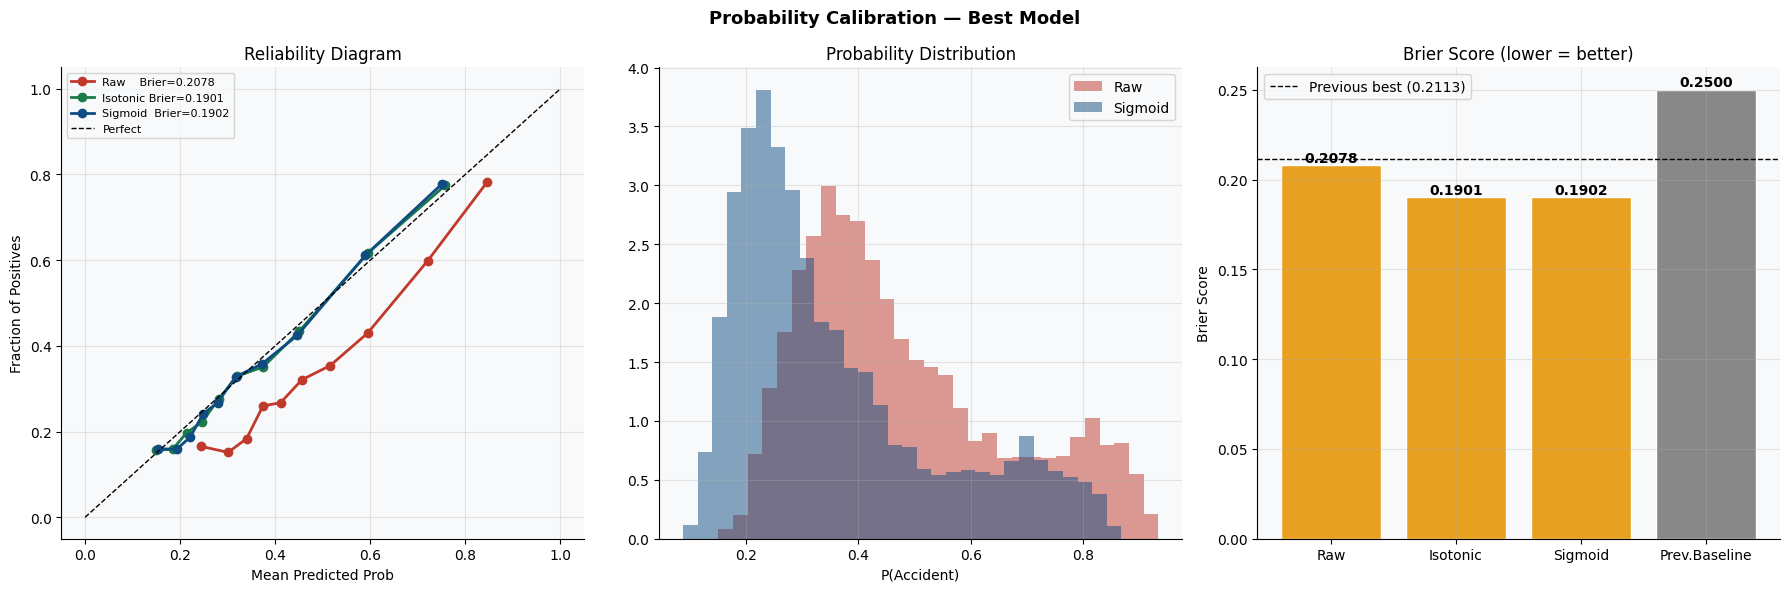

Best calibrated model: HistGradientBoosting + Sigmoid
Calibrated Brier: 0.1902


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Probability Calibration — Best Model', fontsize=13, fontweight='bold')

best_model = results[best_name]['model']

# Calibrate with Sigmoid (Platt) and Isotonic
cal_sigmoid  = CalibratedClassifierCV(best_model, method='sigmoid',  cv=5)
cal_isotonic = CalibratedClassifierCV(best_model, method='isotonic', cv=5)
cal_sigmoid.fit(X_tr.values, y_tr.values)
cal_isotonic.fit(X_tr.values, y_tr.values)

prob_raw      = results[best_name]['y_prob']
prob_sigmoid  = cal_sigmoid.predict_proba(X_te.values)[:,1]
prob_isotonic = cal_isotonic.predict_proba(X_te.values)[:,1]

# Reliability diagrams
ax = axes[0]
for probs, label, color in [
    (prob_raw,      f'Raw    Brier={brier_score_loss(y_te,prob_raw):.4f}',      C[3]),
    (prob_isotonic, f'Isotonic Brier={brier_score_loss(y_te,prob_isotonic):.4f}',C[2]),
    (prob_sigmoid,  f'Sigmoid  Brier={brier_score_loss(y_te,prob_sigmoid):.4f}', C[0]),
]:
    fop, mpv = calibration_curve(y_te, probs, n_bins=10, strategy='quantile')
    ax.plot(mpv, fop, marker='o', color=color, label=label, lw=2)
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax.set_title('Reliability Diagram'); ax.set_xlabel('Mean Predicted Prob')
ax.set_ylabel('Fraction of Positives'); ax.legend(fontsize=8)

# Distribution
ax = axes[1]
ax.hist(prob_raw,      bins=30, alpha=0.5, color=C[3], label='Raw',     density=True)
ax.hist(prob_sigmoid,  bins=30, alpha=0.5, color=C[0], label='Sigmoid', density=True)
ax.set_title('Probability Distribution'); ax.set_xlabel('P(Accident)'); ax.legend()

# Brier scores
ax = axes[2]
labels = ['Raw','Isotonic','Sigmoid','Prev.Baseline']
briers = [brier_score_loss(y_te, p) for p in [prob_raw,prob_isotonic,prob_sigmoid]] + [0.2500]
colors = [C[3] if b<0.18 else C[1] if b<0.22 else '#888888' for b in briers]
bars = ax.bar(labels, briers, color=colors, edgecolor='white')
for bar, val in zip(bars, briers):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Brier Score (lower = better)'); ax.set_ylabel('Brier Score')
ax.axhline(0.2113, color='black', ls='--', lw=1, label='Previous best (0.2113)')
ax.legend()

plt.tight_layout()
plt.savefig('fig_07_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

best_calibrated = cal_sigmoid
brier_cal = brier_score_loss(y_te, prob_sigmoid)
print(f"Best calibrated model: {best_name} + Sigmoid")
print(f"Calibrated Brier: {brier_cal:.4f}")


3.7 Feature Importance

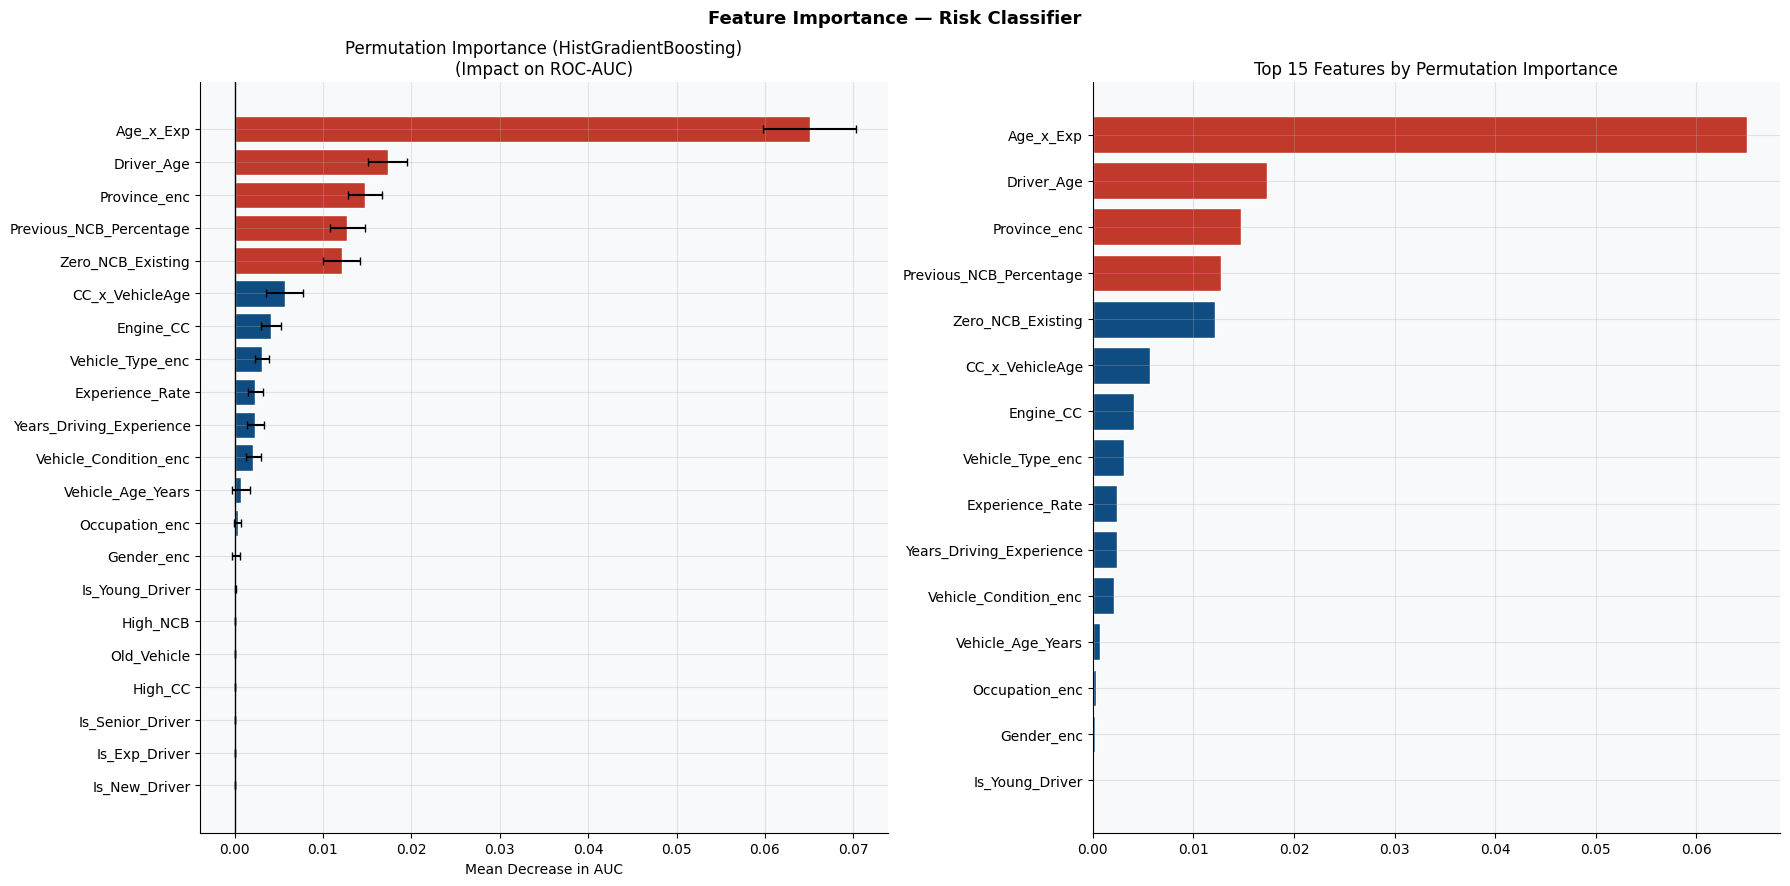

In [11]:

from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Feature Importance — Risk Classifier', fontsize=13, fontweight='bold')

# Permutation importance (model-agnostic, works for all)
pi = permutation_importance(results[best_name]['model'], X_te.values, y_te.values,
                             n_repeats=15, random_state=42, scoring='roc_auc', n_jobs=-1)
feat_imp = pd.Series(pi.importances_mean, index=RISK_FEATURES_NO_RS)
feat_std = pd.Series(pi.importances_std,  index=RISK_FEATURES_NO_RS)
feat_imp_sorted = feat_imp.sort_values()
colors = [C[3] if v>feat_imp.quantile(0.75) else C[0] for v in feat_imp_sorted]

ax = axes[0]
ax.barh(feat_imp_sorted.index, feat_imp_sorted.values,
        xerr=feat_std[feat_imp_sorted.index].values,
        color=colors, edgecolor='white', error_kw={'elinewidth':1.5,'capsize':3})
ax.set_title(f'Permutation Importance ({best_name})\n(Impact on ROC-AUC)')
ax.set_xlabel('Mean Decrease in AUC'); ax.axvline(0, color='black', lw=1)

# Also show native feature importance if available
est = results[best_name]['model']
if hasattr(est, 'named_steps'):
    est = est.named_steps.get('clf', est)
if hasattr(est, 'feature_importances_'):
    fi = pd.Series(est.feature_importances_, index=RISK_FEATURES_NO_RS).sort_values()
    colors2 = [C[3] if v>fi.quantile(0.75) else C[0] for v in fi]
    axes[1].barh(fi.index, fi.values, color=colors2, edgecolor='white')
    axes[1].set_title(f'Native Feature Importance ({best_name})')
    axes[1].set_xlabel('Importance')
else:
    # Fallback: show top-n permutation importance ranked bar
    top15 = feat_imp.nlargest(15).sort_values()
    colors3 = [C[3] if v>top15.quantile(0.75) else C[0] for v in top15]
    axes[1].barh(top15.index, top15.values, color=colors3, edgecolor='white')
    axes[1].set_title(f'Top 15 Features by Permutation Importance')

plt.tight_layout()
plt.savefig('fig_08_feature_imp.png', dpi=150, bbox_inches='tight')
plt.show()


3.8 Save Best Model

In [12]:

# Retrain calibrated model on ALL data
X_all = X_risk.values
y_all = y_risk.values

best_final = results[best_name]['model']
best_final.fit(X_all, y_all)
final_calibrated = CalibratedClassifierCV(best_final, method='sigmoid', cv=5)
final_calibrated.fit(X_all, y_all)

y_prob_final_cal = final_calibrated.predict_proba(X_te.values)[:,1]

save_dict = {
    'model':             final_calibrated,
    'raw_model':         best_final,
    'name':              best_name,
    'features':          RISK_FEATURES_NO_RS,
    'n_features':        len(RISK_FEATURES_NO_RS),
    'test_auc':          results[best_name]['roc_auc'],
    'test_pr_auc':       results[best_name]['pr_auc'],
    'test_f1':           results[best_name]['f1'],
    'test_kappa':        results[best_name]['kappa'],
    'brier_raw':         results[best_name]['brier'],
    'brier_calibrated':  brier_score_loss(y_te, y_prob_final_cal),
    'baseline_auc':      BASELINE_AUC,
    'improvement_auc':   results[best_name]['roc_auc'] - BASELINE_AUC,
    'all_results':       {k:{kk:vv for kk,vv in v.items()
                             if kk not in ['model','y_pred','y_prob']}
                          for k,v in results.items()},
    'ranked':            ranked,
}

with open('../backend/models/risk_classifier.pkl', 'wb') as f:
    pickle.dump(save_dict, f)

print(f"   risk_classifier.pkl saved")
print(f"   Best model         : {best_name}")
print(f"   ROC-AUC            : {results[best_name]['roc_auc']:.4f}")
print(f"   PR-AUC             : {results[best_name]['pr_auc']:.4f}")
print(f"   F1-Score           : {results[best_name]['f1']:.4f}")
print(f"   Cohen Kappa        : {results[best_name]['kappa']:.4f}")
print(f"   Brier (calibrated) : {brier_score_loss(y_te, y_prob_final_cal):.4f}")
print(f"   Features           : {len(RISK_FEATURES_NO_RS)}")


   risk_classifier.pkl saved
   Best model         : HistGradientBoosting
   ROC-AUC            : 0.7274
   PR-AUC             : 0.6160
   F1-Score           : 0.5726
   Cohen Kappa        : 0.3308
   Brier (calibrated) : 0.1829
   Features           : 21
